In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [ ]:
import pandas as pd
df = pd.read_csv('/kaggle/input/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

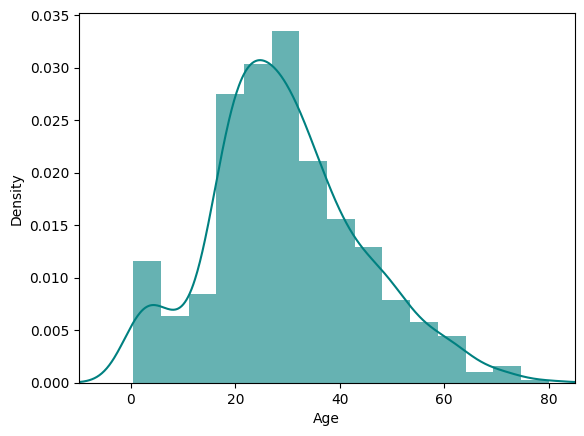

In [ ]:
import matplotlib.pyplot as plt
ax = df['Age'].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
df['Age'].plot(kind='density', color='teal')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.dropna(axis=0, subset=['Embarked'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [ ]:
df.drop(['PassengerId', 'Cabin', 'Ticket'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Name      889 non-null    object 
 3   Sex       889 non-null    object 
 4   Age       889 non-null    float64
 5   SibSp     889 non-null    int64  
 6   Parch     889 non-null    int64  
 7   Fare      889 non-null    float64
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 69.5+ KB


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
embarked_onehot = encoder.fit_transform(df[['Embarked']]).toarray()
one_hot_df = pd.DataFrame(embarked_onehot, columns=encoder.get_feature_names_out())
one_hot_df.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [ ]:
df.drop(['Embarked'],axis=1,inplace=True)
df = pd.concat([df,one_hot_df], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 829
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    float64
 1   Pclass      889 non-null    float64
 2   Name        889 non-null    object 
 3   Sex         889 non-null    object 
 4   Age         889 non-null    float64
 5   SibSp       889 non-null    float64
 6   Parch       889 non-null    float64
 7   Fare        889 non-null    float64
 8   Embarked_C  889 non-null    float64
 9   Embarked_Q  889 non-null    float64
 10  Embarked_S  889 non-null    float64
dtypes: float64(9), object(2)
memory usage: 83.5+ KB


In [ ]:
pd.unique(df.Sex)

array(['male', 'female', nan], dtype=object)

In [ ]:
df.dropna(axis=0, subset=['Sex'],inplace=True)
df['Sex'] = df['Sex'].astype('category')
pd.unique(df.Sex)

['male', 'female']
Categories (2, object): ['female', 'male']

In [ ]:
encoder=OneHotEncoder()
sex_onehot=encoder.fit_transform(df[['Sex']]).toarray()
one_hot_df=pd.DataFrame(sex_onehot,columns=encoder.get_feature_names_out())
one_hot_df.head()

,Sex_female,Sex_male
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0


In [ ]:
df.drop(['Sex'],axis=1,inplace=True)
df=pd.concat([df,one_hot_df],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 829
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    float64
 1   Pclass      889 non-null    float64
 2   Name        889 non-null    object 
 3   Age         889 non-null    float64
 4   SibSp       889 non-null    float64
 5   Parch       889 non-null    float64
 6   Fare        889 non-null    float64
 7   Embarked_C  887 non-null    float64
 8   Embarked_Q  887 non-null    float64
 9   Embarked_S  887 non-null    float64
 10  Sex_female  889 non-null    float64
 11  Sex_male    889 non-null    float64
dtypes: float64(11), object(1)
memory usage: 90.5+ KB


In [ ]:
df.dropna(axis=0, subset=['Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Sex_female', 'Sex_male'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 887 entries, 0 to 888
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    887 non-null    float64
 1   Pclass      887 non-null    float64
 2   Name        887 non-null    object 
 3   Age         887 non-null    float64
 4   SibSp       887 non-null    float64
 5   Parch       887 non-null    float64
 6   Fare        887 non-null    float64
 7   Embarked_C  887 non-null    float64
 8   Embarked_Q  887 non-null    float64
 9   Embarked_S  887 non-null    float64
 10  Sex_female  887 non-null    float64
 11  Sex_male    887 non-null    float64
dtypes: float64(11), object(1)
memory usage: 90.1+ KB


In [ ]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
Sex_female    0
Sex_male      0
dtype: int64

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
or_enc = OrdinalEncoder()
pclass_encod = or_enc.fit_transform(df[['Pclass']])
pclass_df = pd.DataFrame(pclass_encod, columns = or_enc.get_feature_names_out())
pclass_df.head

<bound method NDFrame.head of      Pclass
0       2.0
1       0.0
2       2.0
3       0.0
4       2.0
..      ...
882     2.0
883     2.0
884     1.0
885     0.0
886     2.0

[887 rows x 1 columns]>